# Estudio Analítico: Splits y Fronteras de Decisión en Árboles de Clasificación

**Autor:** Jorge Fernando De Los Ríos  
**Licencia:** MIT  
**Año:** 2026

## 1. Propósito y alcance

Este notebook presenta un análisis controlado del funcionamiento interno de los árboles de decisión, con énfasis en la mecánica de splits y la construcción de fronteras de decisión.

Con este fin, se desarrolla y examina un ejercicio práctico a partir de un dataset sintético, diseñado específicamente para aislar, controlar y visualizar estos conceptos de manera clara y didáctica.

Dado que el objetivo principal de este trabajo es la comprensión teórica del algoritmo y la exploración de su comportamiento interno —y no la construcción de un modelo orientado a producción ni la optimización de su desempeño predictivo o estructural— se omiten de forma deliberada diversas prácticas habituales de ingeniería de *machine learning*, entre ellas:

* análisis exploratorio de datos (*EDA*)
* separación en conjuntos de entrenamiento y prueba (*train/test split*)
* validación cruzada
* ajuste de hiperparámetros
* poda (*pruning*) y optimización estructural del árbol
* búsqueda de la profundidad óptima
* evaluación formal mediante métricas
* construcción de *pipelines*
* *feature engineering*

En particular, la omisión del *EDA* responde a que el dataset no constituye el objeto de estudio, sino un recurso experimental controlado, construido específicamente para representar un escenario didáctico. Por esta razón, no resulta necesario analizar distribuciones, valores atípicos o relaciones estadísticas, dado que tales características fueron definidas previamente de forma intencional.

De manera análoga, las demás omisiones obedecen a la necesidad de preservar el foco en el objetivo central del notebook: comprender la mecánica interna del algoritmo y la geometría de sus decisiones, en lugar de abordar aspectos relacionados con optimización, capacidad de generalización o mejora del rendimiento del modelo.

## 2. Construcción del dataset sintetico

Para no tener que profundizar en conceptos que no tienen que ver con el objetivo que se desea estudiar, se construye un dataset sintetico, el cual:

* no va a tener datos nulos
* no va a tener registros duplicados
* todos los tipos de datos van a ser enteros
* la variable objetivo está balanceada

In [81]:
import pandas as pd

df = pd.DataFrame(
    [
        {"x0":14, "x1":19, "clase":0},
        {"x0":9,  "x1":15, "clase":0},
        {"x0":16, "x1":10, "clase":0},
        {"x0":5,  "x1":9,  "clase":0},
        {"x0":18, "x1":7,  "clase":0},
        {"x0":1,  "x1":6,  "clase":0},
        {"x0":20, "x1":6,  "clase":0},
        {"x0":19, "x1":4,  "clase":0},
        {"x0":3,  "x1":3,  "clase":0},
        {"x0":4,  "x1":1,  "clase":0},
        {"x0":10, "x1":10, "clase":1},
        {"x0":13, "x1":10, "clase":1},
        {"x0":9,  "x1":8,  "clase":1},
        {"x0":16, "x1":7,  "clase":1},
        {"x0":8,  "x1":7,  "clase":1},
        {"x0":11, "x1":6,  "clase":1},
        {"x0":14, "x1":5,  "clase":1},
        {"x0":12, "x1":4,  "clase":1},
        {"x0":10, "x1":3,  "clase":1},
        {"x0":15, "x1":2,  "clase":1},
    ]
)

Cabe resaltar que el dataframe está basado en información extraida del video [Clasificación con Árboles de Decisión ¡EN 15 MINUTOS!](https://www.youtube.com/watch?v=kqaLlte6P6o)

El objetivo es predecir la etiqueta clase usando los atributos x0 y x1.

In [82]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np

# Generar los datos
X, y = make_classification(
    n_samples=20,           # 20 muestras
    n_features=2,           # 2 características (x0, x1)
    n_informative=2,        # ambas características son informativas
    n_redundant=0,          # sin características redundantes
    n_clusters_per_class=1, # 1 cluster por clase
    n_classes=2,            # 2 clases
    class_sep=0.8,          # separación entre clases (ajustable)
    random_state=42         # para reproducibilidad
)

# Crear el DataFrame
df = pd.DataFrame(X, columns=['x0', 'x1'])
df['clase'] = y

print(df)

          x0        x1  clase
0   1.131059  2.045238      0
1  -0.907099  0.895919      0
2  -0.185810  0.773612      1
3   1.231872  1.845483      0
4  -1.800897 -0.012292      0
5   0.107587  1.109199      1
6  -0.394330  1.024167      0
7   2.151794  0.544496      1
8   1.303276  1.218717      1
9  -0.534937  1.265919      1
10  0.748254  0.413202      1
11  0.741948  1.158242      1
12 -2.718322 -0.125871      0
13  1.225146  1.350983      1
14 -0.151771  1.177300      1
15  0.741077  1.321263      0
16 -0.252247  1.306057      0
17  0.994133  1.017169      1
18 -2.797733 -0.428311      0
19  0.005002  1.244472      0


## 3. Visualización inicial

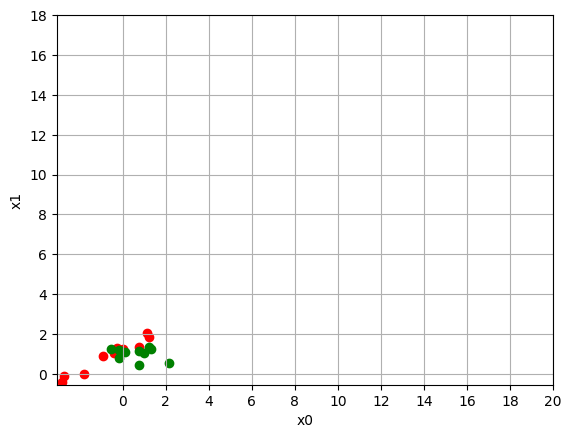

In [83]:
# Separar clases
rojos = df[df["clase"] == 0]
verdes = df[df["clase"] == 1]

import matplotlib.pyplot as plt

plt.scatter(
    rojos["x0"],
    rojos["x1"],
    color="red"
)

plt.scatter(
    verdes["x0"],
    verdes["x1"],
    color="green"
)

# Configuración del gráfico
plt.xlabel("x0")
plt.ylabel("x1")

plt.xticks(range(0, 22, 2))
plt.yticks(range(0, 20, 2))

plt.grid(True)

plt.show()

## 4. Preparación de variables

In [84]:
feature_cols  = df[['x0', 'x1']]
target_col  = df['clase']

## 5. Entrenamiento del modelo

In [85]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

modelo = DecisionTreeClassifier(
        criterion = 'gini',
        max_depth = 4, # Profundidad máxima
        #min_samples_split = 11#, # Mínimo de muestras para generar partición
        #min_samples_leaf = 1, # Mínimo de muestras que pueden quedar en una hoja
        random_state=42
        )

## 6. Interpretación del árbol

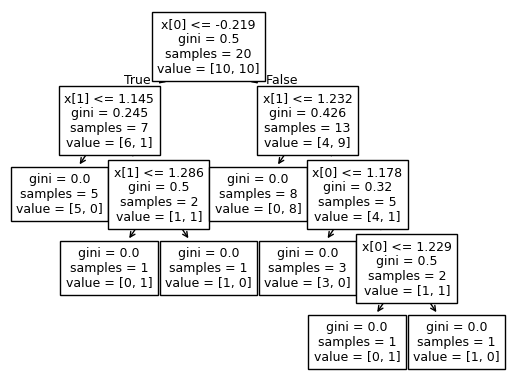

In [86]:
modelo.fit(feature_cols, target_col)

plot_tree(
    decision_tree = modelo,
    #impurity = False,
    fontsize = 9
    )

plt.show()

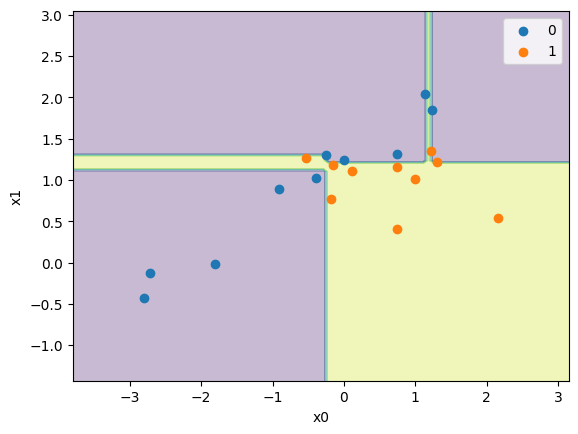

In [87]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

# Dibujar frontera de decisión
DecisionBoundaryDisplay.from_estimator(
    modelo,
    feature_cols,
    response_method="predict",
    xlabel="x0",
    ylabel="x1",
    alpha=0.3
)

# Dibujar puntos originales
for clase in target_col.unique():
    idx = target_col == clase
    plt.scatter(
        feature_cols.loc[idx, "x0"],
        feature_cols.loc[idx, "x1"],
        label=clase
    )

plt.legend()
plt.show()

## 7. Conclusiones

Este ejercicio permitió comprender cómo un árbol de decisión construye reglas de clasificación a partir de divisiones sucesivas sobre las variables de entrada.

Se observó que cada split tiene como objetivo reducir la impureza de los nodos, generando particiones progresivamente más específicas hasta alcanzar regiones con mayor homogeneidad en las clases.

La visualización del árbol facilitó la interpretación de la secuencia de decisiones tomadas por el modelo, permitiendo identificar qué variables y umbrales influyen directamente en la clasificación.

Asimismo, la representación de la frontera de decisión permitió evidenciar cómo la estructura interna del árbol se traduce en particiones concretas dentro del espacio de características.

Finalmente, se comprobó que la profundidad del árbol influye directamente en la complejidad de las reglas generadas, afectando el nivel de detalle con el que el modelo segmenta los datos.

# 8. Pendiente

* Iterar sobre la profundidad en un bucle para mostrar cómo evoluciona el sobreajuste;

* Usar make_classification de sklearn en vez de pandas para generar el dataframe

* ¿Qué pasa si cambiamos la profundidad? ¿Y el criterio de impureza (gini vs entropía)?

* Incluir una reflexión sobre bias-variance tradeoff aunque sea breve